In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from src.analysis.data import load_experiment_result_data

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.style.use('default')
pd.set_option('mode.copy_on_write', True)

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
magnetization = load_experiment_result_data('../../results/erdos_renyi/magnetization.csv')

In [41]:
#returns = np.log(np.abs(data)) - np.log(np.abs(data.shift(1)))

returns = magnetization - magnetization.shift(1)
returns = returns.loc[500:]

In [42]:
magnetization.loc[500:]

alpha    10                                      20                    ...  \
beta    0.2    0.4    0.6    0.8    1.0    1.2  0.2   0.4   0.6   0.8  ...   
500     674  10820 -14316 -16176 -16750 -17360  412  5774 -7242 -7512  ...   
501     658  10852 -14312 -16118 -16810 -17508  612  5554 -7108 -7354  ...   
502     750  11142 -14170 -15646 -16562 -17062  724  5590 -7098 -7554  ...   
503      74  10884 -14574 -15702 -16820 -17534  108  5214 -7418 -7900  ...   
504     -52  10484 -14574 -15962 -16780 -17828  -36  5120 -7216 -8214  ...   
...     ...    ...    ...    ...    ...    ...  ...   ...   ...   ...  ...   
2996   -348  10416 -14858 -16306 -16912 -17294 -194  5262 -7602 -7576  ...   
2997   -230  10534 -14768 -16278 -16894 -17404  -34  5266 -7624 -7972  ...   
2998   -432  10448 -14448 -16064 -16906 -17490 -272  5296 -7340 -7872  ...   
2999  -1008  10148 -14470 -15956 -17128 -17752 -914  5024 -7456 -7660  ...   
3000   -724  10788 -14290 -15752 -16894 -17408 -688  5574 -6866 -7630  ...   

alpha    40                     50                                
beta    0.6   0.8   1.0   1.2  0.2   0.4   0.6   0.8   1.0   1.2  
500   -3362 -3912 -3708 -4014  414  2210 -2436 -3112 -2942 -2924  
501   -3340 -3790 -3978 -4002  554  2254 -2108 -3100 -3156 -3368  
502   -3216 -3786 -3358 -3870  734  2694 -1962 -2720 -2988 -3372  
503   -3682 -3986 -3912 -4038  162  2230 -2558 -3086 -3314 -3044  
504   -3504 -3926 -4048 -4094  -14  2114 -3126 -3248 -3362 -3102  
...     ...   ...   ...   ...  ...   ...   ...   ...   ...   ...  
2996  -3350 -3696 -3828 -4146   14  1500 -2862 -2998 -3236 -3144  
2997  -3324 -3906 -3766 -4118  148  1898 -2976 -2970 -3386 -3012  
2998  -3666 -4134 -4076 -4208 -134  2048 -3110 -3234 -3174 -3224  
2999  -3684 -4178 -3868 -3892 -606  1972 -3166 -3176 -3208 -3380  
3000  -3098 -3546 -3974 -3744 -376  2416 -2642 -3258 -3066 -2986  

[2501 rows x 30 columns]

In [43]:
from statsmodels.tsa.stattools import acf, pacf


def compute_metrics(returns: pd.DataFrame, lag: int = 1, warmup: int = 500) -> dict[str, np.ndarray]:
    """
    Compute statistical metrics for each (alpha, beta) parameter pair.
    
    Parameters
    ----------
    returns : pd.DataFrame
        DataFrame with MultiIndex columns ('alpha', 'beta')
    lag : int, default=1
        Lag for ACF/PACF computation
    warmup : int, default=500
        Number of initial observations to drop
        
    Returns
    -------
    dict[str, np.ndarray]
        Dictionary containing 2D arrays for each metric:
        - 'skewness': Skewness of returns
        - 'kurtosis': Excess kurtosis of returns
        - 'acf_ret': ACF of returns at specified lag
        - 'pacf_ret': PACF of returns at specified lag
        - 'acf_abs_ret': ACF of absolute returns at specified lag
        - 'acf_squared_ret': ACF of squared returns at specified lag
    """
    alpha_values = returns.columns.levels[0]
    beta_values = returns.columns.levels[1]
    n_alpha = len(alpha_values)
    n_beta = len(beta_values)
    
    # Initialize metric arrays
    metrics = {
        'skewness': np.zeros((n_alpha, n_beta)),
        'kurtosis': np.zeros((n_alpha, n_beta)),
        'acf_ret': np.zeros((n_alpha, n_beta)),
        'pacf_ret': np.zeros((n_alpha, n_beta)),
        'acf_abs_ret': np.zeros((n_alpha, n_beta)),
        'acf_squared_ret': np.zeros((n_alpha, n_beta))
    }
    
    # Compute metrics for each parameter pair
    for i, alpha in enumerate(alpha_values):
        for j, beta in enumerate(beta_values):
            series = returns[(alpha, beta)].dropna()[warmup:]
            
            # Skewness and kurtosis
            metrics['skewness'][i, j] = stats.skew(series)
            metrics['kurtosis'][i, j] = stats.kurtosis(series)
            
            # ACF and PACF for returns
            acf_values = acf(series, nlags=lag, fft=False)
            pacf_values = pacf(series, nlags=lag)
            metrics['acf_ret'][i, j] = acf_values[lag]
            metrics['pacf_ret'][i, j] = pacf_values[lag]
            
            # ACF for absolute returns
            acf_abs = acf(series.abs(), nlags=lag, fft=False)
            metrics['acf_abs_ret'][i, j] = acf_abs[lag]
            
            # ACF for squared returns
            acf_squared = acf(series ** 2, nlags=lag, fft=False)
            metrics['acf_squared_ret'][i, j] = acf_squared[lag]
    
    return metrics


def plot_metric_heatmap(
    metric_array: np.ndarray,
    alpha_values: pd.Index,
    beta_values: pd.Index,
    title: str,
    cbar_label: str,
    figsize: tuple[int, int] = (8, 6),
    annot: bool = True,
    cmap: str = 'coolwarm',
    fmt: str = '.3f',
    center: float = None,
    vmin: float = None,
    vmax: float = None
) -> None:
    """
    Plot a heatmap for a given metric with enhanced visual style.
    
    Parameters
    ----------
    metric_array : np.ndarray
        2D array containing metric values
    alpha_values : pd.Index
        Alpha parameter values for y-axis
    beta_values : pd.Index
        Beta parameter values for x-axis
    title : str
        Title for the plot
    cbar_label : str
        Label for the colorbar
    figsize : tuple[int, int], default=(8, 6)
        Figure size
    annot : bool, default=True
        Whether to annotate cells with values
    cmap : str, default='coolwarm'
        Colormap name
    fmt : str, default='.3f'
        Format string for annotations
    center : float, optional
        Value at which to center the colormap
    vmin : float, optional
        Minimum value for colormap
    vmax : float, optional
        Maximum value for colormap
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Prepare heatmap kwargs
    heatmap_kwargs = {
        'data': metric_array,
        'annot': annot,
        'fmt': fmt,
        'xticklabels': beta_values,
        'yticklabels': alpha_values,
        'cmap': cmap,
        'square': True,
        'linewidths': 0.5,
        'linecolor': 'white',
        'cbar_kws': {
            'label': cbar_label,
            'shrink': 0.8
        },
        'annot_kws': {'size': 9},
        'ax': ax
    }
    
    # Add optional parameters if provided
    if center is not None:
        heatmap_kwargs['center'] = center
    if vmin is not None:
        heatmap_kwargs['vmin'] = vmin
    if vmax is not None:
        heatmap_kwargs['vmax'] = vmax
    
    sns.heatmap(**heatmap_kwargs)
    
    # Enhanced title and labels
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Beta (β)', fontsize=12)
    ax.set_ylabel('Alpha (α)', fontsize=12)
    
    # Rotate tick labels for better readability
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va='center')
    
    plt.tight_layout()
    plt.show()

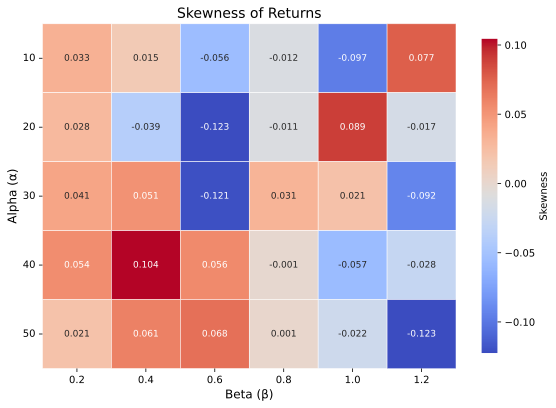

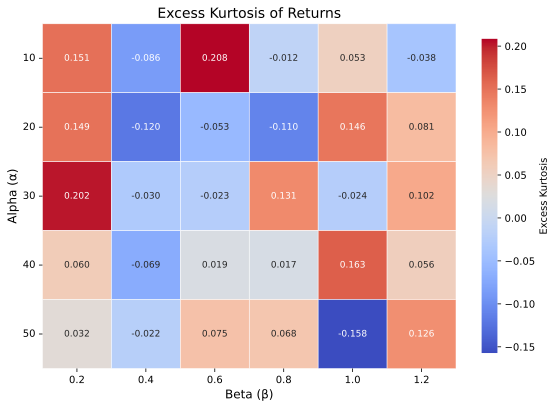

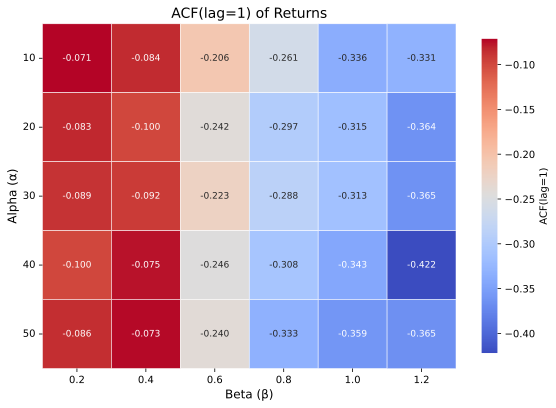

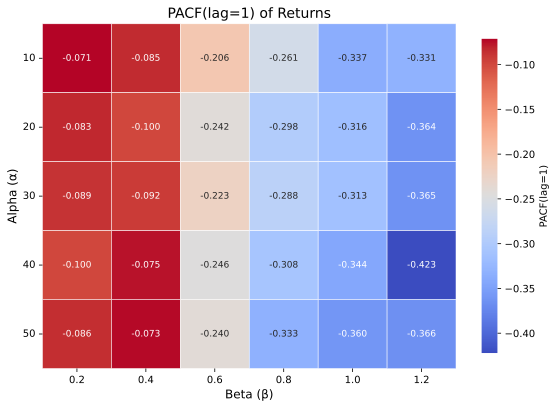

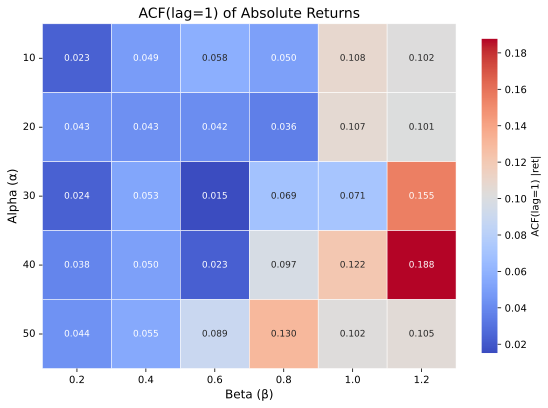

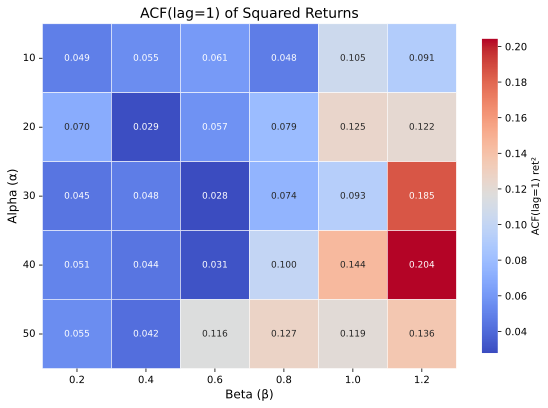

In [44]:
# Compute all metrics
metrics = compute_metrics(returns, lag=1, warmup=500)

# Get parameter values for plotting
alpha_values = returns.columns.levels[0]
beta_values = returns.columns.levels[1]

# Plot each metric
plot_metric_heatmap(
    metrics['skewness'],
    alpha_values,
    beta_values,
    title='Skewness of Returns',
    cbar_label='Skewness'
)

plot_metric_heatmap(
    metrics['kurtosis'],
    alpha_values,
    beta_values,
    title='Excess Kurtosis of Returns',
    cbar_label='Excess Kurtosis'
)

plot_metric_heatmap(
    metrics['acf_ret'],
    alpha_values,
    beta_values,
    title='ACF(lag=1) of Returns',
    cbar_label='ACF(lag=1)'
)

plot_metric_heatmap(
    metrics['pacf_ret'],
    alpha_values,
    beta_values,
    title='PACF(lag=1) of Returns',
    cbar_label='PACF(lag=1)'
)

plot_metric_heatmap(
    metrics['acf_abs_ret'],
    alpha_values,
    beta_values,
    title='ACF(lag=1) of Absolute Returns',
    cbar_label='ACF(lag=1) |ret|'
)

plot_metric_heatmap(
    metrics['acf_squared_ret'],
    alpha_values,
    beta_values,
    title='ACF(lag=1) of Squared Returns',
    cbar_label='ACF(lag=1) ret²'
)

<Axes: >

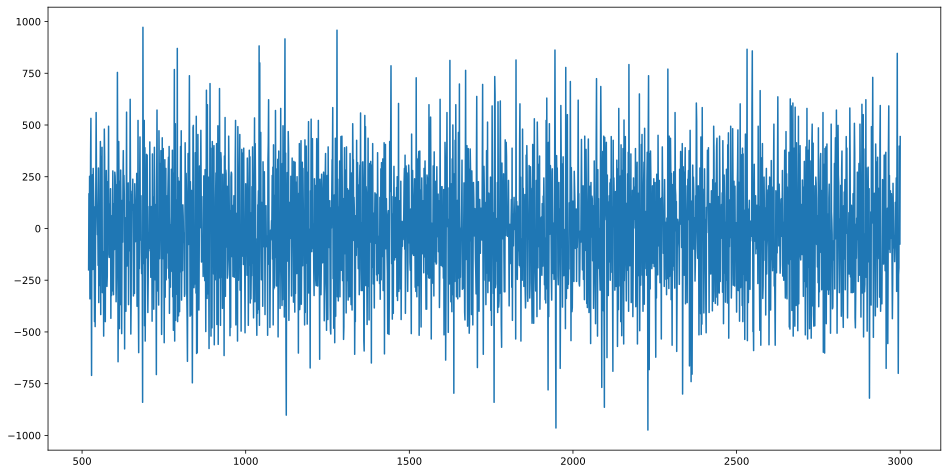

In [45]:
plt.figure(figsize=(16, 8))
returns[(50, 0.4)][20:].plot()

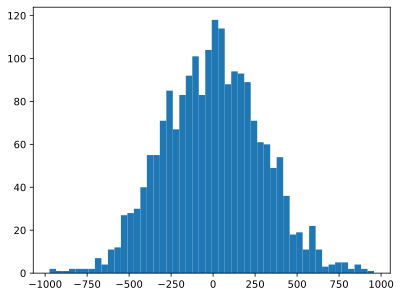

In [46]:
plt.hist(returns[(50, 0.4)][500:], bins=50)
plt.show()

In [47]:
returns.columns.levels[0]

Index([10, 20, 30, 40, 50], dtype='int64', name='alpha')

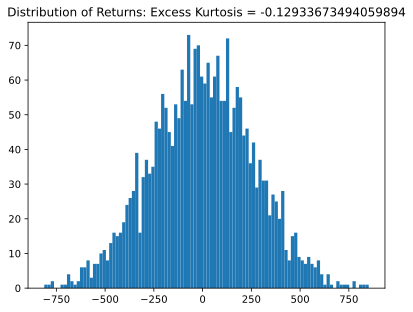

In [48]:
def plot_return_distribution(returns, save = True):
    #returns = np.log(self.M_t_values/self.M_t_values.shift(1))
    excess_kurtosis = stats.kurtosis(returns[np.isfinite(returns)])
    plt.hist(returns[np.isfinite(returns)], bins=100)
    plt.title(f'Distribution of Returns: Excess Kurtosis = {excess_kurtosis}')
    #if save == True: 
        #plt.savefig(path + 'return_distribution.png')

    plt.show()

plot_return_distribution(returns[20, 0.8], save = False)

/var/folders/q_/2nhldr_d2x723c91y7qt5g2r0000gn/T/ipykernel_27816/862248566.py:13: RuntimeWarning: invalid value encountered in log
  kurt_values = np.log([stats.kurtosis(returns[np.isfinite(returns)][col].dropna()) for col in returns.columns])


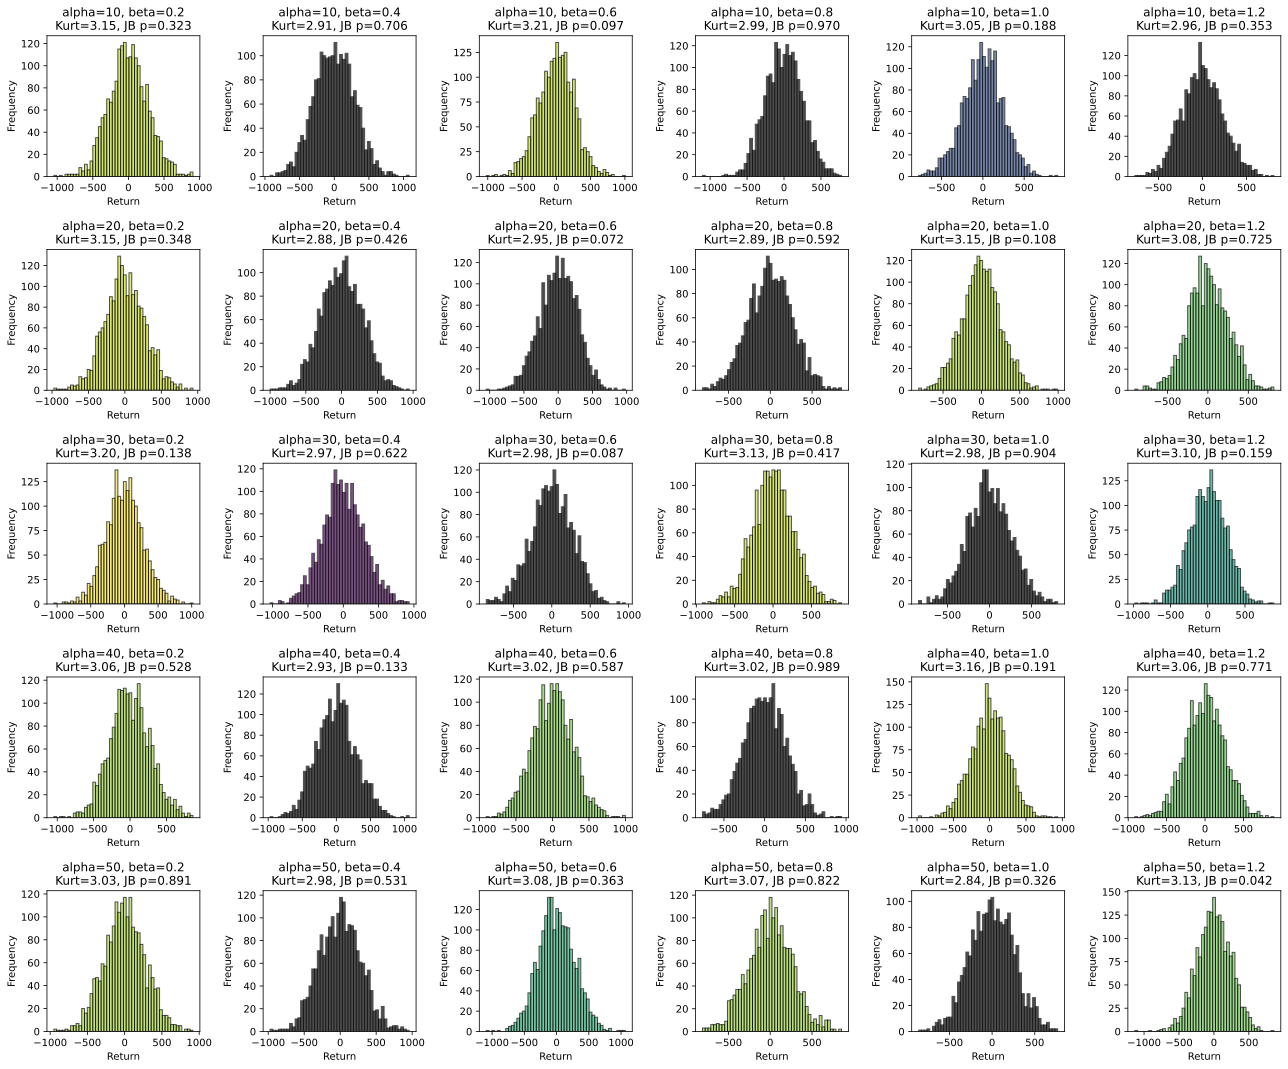

In [49]:
from matplotlib import cm

# ploting the distribution and kurtosis of $\beta$, and use Jarque-Bera test to test the normality of the distribution.

# Create a 5x6 grid of subplots
n_rows, n_cols = 5, 6
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 15))

# Flatten axes for easier iteration
axes = axes.flatten()

# Compute kurtosis for all columns and normalize for colormap
kurt_values = np.log([stats.kurtosis(returns[np.isfinite(returns)][col].dropna()) for col in returns.columns])
kurt_min, kurt_max = min(kurt_values), max(kurt_values)
norm_kurt = [(k - kurt_min) / (kurt_max - kurt_min) for k in kurt_values]  # Normalize between 0 and 1

# Iterate over each (alpha, beta) pair and plot the distribution
for idx, (col, ax) in enumerate(zip(returns.columns, axes)):
    #print(returns[np.isfinite(returns)][col].dropna())
    series = returns[np.isfinite(returns)][col].dropna()[500:]
    
    
    # Compute kurtosis and Jarque-Bera test
    kurt = stats.kurtosis(series, fisher=False)
    jb_stat, jb_p = stats.jarque_bera(series)

    color = cm.viridis(norm_kurt[idx])
    
    # Set title with kurtosis and p-value
    ax.hist(series, bins=50, edgecolor='k', alpha=0.7, color = color)
    ax.set_title(f'alpha={col[0]}, beta={col[1]}\nKurt={kurt:.2f}, JB p={jb_p:.3f}')
    ax.set_xlabel('Return')
    ax.set_ylabel('Frequency')
    #ax.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

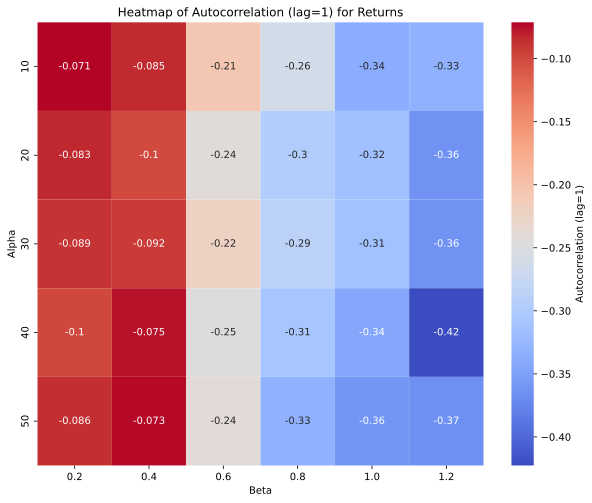

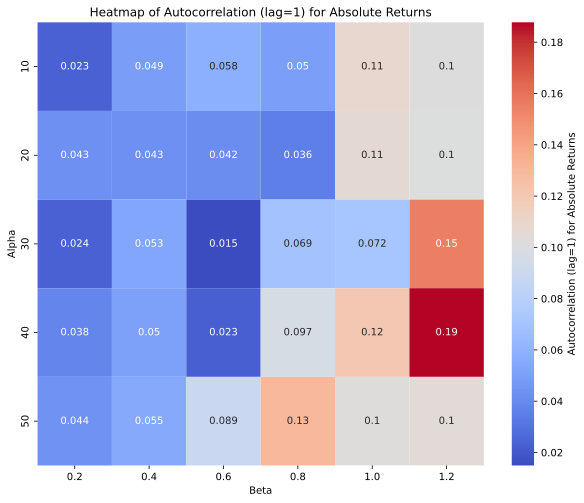

In [50]:
# Assuming 'returns' DataFrame is already loaded with MultiIndex columns ('alpha', 'beta')

# Function to compute autocorrelation for a given lag
def autocorrelation(series, lag=1):
    return series.autocorr(lag)

# Define parameters for heatmap
alpha_values = returns.columns.levels[0]
beta_values = returns.columns.levels[1]
n_alpha = len(alpha_values)
n_beta = len(beta_values)

# Initialize heatmaps for return and absolute return
autocorr_heatmap = np.zeros((n_alpha, n_beta))
abs_autocorr_heatmap = np.zeros((n_alpha, n_beta))

# Compute autocorrelation for lag=1 for each (alpha, beta) pair
for i, alpha in enumerate(alpha_values):
    for j, beta in enumerate(beta_values):
        series = returns[(alpha, beta)].dropna()[500:]
        autocorr_heatmap[i, j] = autocorrelation(series, lag=1)
        abs_autocorr_heatmap[i, j] = autocorrelation(series.abs(), lag=1)

# Plot heatmap for autocorrelation of returns using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(autocorr_heatmap, annot=True, xticklabels=beta_values, yticklabels=alpha_values, cmap='coolwarm', cbar_kws={'label': 'Autocorrelation (lag=1)'})
plt.title('Heatmap of Autocorrelation (lag=1) for Returns')
plt.xlabel('Beta')
plt.ylabel('Alpha')
plt.show()

# Plot heatmap for autocorrelation of absolute returns using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(abs_autocorr_heatmap, annot=True, xticklabels=beta_values, yticklabels=alpha_values, cmap='coolwarm', cbar_kws={'label': 'Autocorrelation (lag=1) for Absolute Returns'})
plt.title('Heatmap of Autocorrelation (lag=1) for Absolute Returns')
plt.xlabel('Beta')
plt.ylabel('Alpha')
plt.show()